# 玉米公开组学数据集 - 过滤与描述性统计

本 notebook 对 `eutilies.py` 收集的两份结果做清洗、过滤与描述性统计：

- `maize_sra_omics_dataset.csv`：Run 级 SRA 元数据（25 列，含数据量/下载/访问控制/文献关联）
- `maize_bioproject_summary.csv`：BioProject 项目级描述（9 列，含 GEO/机构/农学相关性）

数据来源于 NCBI SRA / BioProject（检索式限定 Zea mays + 单细胞/空间、ATAC/染色质可及性、Bulk RNA-seq×胁迫/组织/品系）。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)

OUT = '/mnt/rice/default/Workspace/yangdong/ai4research/P-maize/out'

In [2]:
sra = pd.read_csv(f'{OUT}/maize_sra_omics_dataset.csv', low_memory=False)
bp = pd.read_csv(f'{OUT}/maize_bioproject_summary.csv', low_memory=False)

print('SRA shape:', sra.shape)
print('BioProject shape:', bp.shape)
sra.head(3)

SRA shape: (57298, 25)
BioProject shape: (1523, 9)


,Run,BioProject,SRAStudy,Experiment,Sample,BioSample,SampleName,LibraryStrategy,LibrarySelection,LibrarySource,LibraryLayout,Platform,Model,TaxID,ScientificName,ReleaseDate,spots,bases,size_MB,avgLength,download_path,Study_Pubmed_id,Consent,CenterName,Omics_Category
0,ERR17711423,PRJEB123674,ERP203586,ERX17102224,ERS31054303,SAMEA123305475,SAMEA123305475,RNA-Seq,cDNA,TRANSCRIPTOMIC,PAIRED,ILLUMINA,HiSeq X Ten,4577,Zea mays,2026-09-02 20:02:34,3108354,932506200,651,300,https://sra-pub-run-odp.s3.amazonaws.com/sra/E...,NaN,public,KEYGENE N.V.,Bulk RNA-seq
1,ERR17711429,PRJEB123674,ERP203586,ERX17102230,ERS31054304,SAMEA123305476,SAMEA123305476,RNA-Seq,cDNA,TRANSCRIPTOMIC,PAIRED,ILLUMINA,HiSeq X Ten,4577,Zea mays,2026-09-02 20:02:34,3508140,1052442000,725,300,https://sra-pub-run-odp.s3.amazonaws.com/sra/E...,NaN,public,KEYGENE N.V.,Bulk RNA-seq
2,ERR17711445,PRJEB123674,ERP203586,ERX17102246,ERS31054306,SAMEA123305478,SAMEA123305478,RNA-Seq,cDNA,TRANSCRIPTOMIC,PAIRED,ILLUMINA,HiSeq X Ten,4577,Zea mays,2026-09-02 20:02:34,3677949,1103384700,768,300,https://sra-pub-run-odp.s3.amazonaws.com/sra/E...,NaN,public,KEYGENE N.V.,Bulk RNA-seq


In [3]:
# 数值列与日期列清洗
for col in ['spots', 'bases', 'size_MB', 'avgLength']:
    sra[col] = pd.to_numeric(sra[col], errors='coerce')

sra['ReleaseDate'] = pd.to_datetime(sra['ReleaseDate'], errors='coerce')
sra['Year'] = sra['ReleaseDate'].dt.year
print('清洗完成，行数:', len(sra))

清洗完成，行数: 57298


In [4]:
# 去重与唯一性统计
print('原始行数:', len(sra))
print('唯一 Run:', sra['Run'].nunique())
print('重复 Run 行数(第2+次出现):', int(sra['Run'].duplicated().sum()))

sra = sra.drop_duplicates(subset='Run').copy()
print('去重后行数:', len(sra))
print('唯一 BioSample:', sra['BioSample'].nunique())
print('唯一 BioProject:', sra['BioProject'].nunique())
print('唯一 SRAStudy:', sra['SRAStudy'].nunique())

原始行数: 57298
唯一 Run: 57298
重复 Run 行数(第2+次出现): 0
去重后行数: 57298
唯一 BioSample: 49535
唯一 BioProject: 1802
唯一 SRAStudy: 1813


In [5]:
print('=== Omics_Category 分布 ===')
print(sra['Omics_Category'].value_counts(dropna=False))

=== Omics_Category 分布 ===
Omics_Category
Bulk RNA-seq                    53096
Single-Cell/Spatial              2617
Other                             887
ATAC-seq                          529
ChIP-seq                           62
Single-Cell/Spatial;ATAC-seq       61
ATAC-seq;Bulk RNA-seq              30
ChIP-seq;Bulk RNA-seq              10
ATAC-seq;ChIP-seq                   6
Name: count, dtype: int64


In [6]:
for col in ['LibraryStrategy', 'LibrarySource', 'LibraryLayout', 'Platform']:
    print(f'=== {col} 分布 (Top10) ===')
    print(sra[col].value_counts(dropna=False).head(10))
    print()

=== LibraryStrategy 分布 (Top10) ===
LibraryStrategy
RNA-Seq          54045
ncRNA-Seq          853
ATAC-seq           595
OTHER              523
miRNA-Seq          496
AMPLICON           250
WGA                196
Bisulfite-Seq       82
WGS                 66
ChIP-Seq            59
Name: count, dtype: int64

=== LibrarySource 分布 (Top10) ===
LibrarySource
TRANSCRIPTOMIC                52443
TRANSCRIPTOMIC SINGLE CELL     2583
GENOMIC                        1681
METATRANSCRIPTOMIC              275
METAGENOMIC                     150
GENOMIC SINGLE CELL              90
OTHER                            75
SYNTHETIC                         1
Name: count, dtype: int64

=== LibraryLayout 分布 (Top10) ===
LibraryLayout
PAIRED    37182
SINGLE    20116
Name: count, dtype: int64

=== Platform 分布 (Top10) ===
Platform
ILLUMINA           54889
BGISEQ              1624
DNBSEQ               504
PACBIO_SMRT          163
OXFORD_NANOPORE       45
ABI_SOLID             32
ELEMENT               16
ION_TORRENT 

In [7]:
print('=== TaxID 分布 ===')
print(sra['TaxID'].value_counts(dropna=False))

=== TaxID 分布 ===
TaxID
4577      55638
381124     1549
76912        81
4579         23
334825        5
112001        2
Name: count, dtype: int64


In [8]:
print('总碱基数 (Gb):', round(sra['bases'].sum() / 1e9, 1))
print('总 reads (M):', round(sra['spots'].sum() / 1e6, 1))
print('估计存储 (TB):', round(sra['size_MB'].sum() / 1e6, 2))
print('平均读长 (bp):', round(sra['avgLength'].mean(), 1))
print()

summary = sra.groupby('Omics_Category')['bases'].agg(['count', 'sum', 'median'])
summary['sum_Gb'] = (summary['sum'] / 1e9).round(1)
summary['median_Gb'] = (summary['median'] / 1e9).round(2)
print('按 Omics_Category 汇总碱基数据量:')
print(summary)

总碱基数 (Gb): 310335.6
总 reads (M): 1416298.9
估计存储 (TB): 118.66
平均读长 (bp): 213.0

按 Omics_Category 汇总碱基数据量:
                              count              sum        median    sum_Gb  \
Omics_Category                                                                 
ATAC-seq                        529    7400689943293  9.752812e+09    7400.7   
ATAC-seq;Bulk RNA-seq            30     127164575300  5.062630e+08     127.2   
ATAC-seq;ChIP-seq                 6      55994313424  1.123611e+10      56.0   
Bulk RNA-seq                  53096  273504496013651  4.355738e+09  273504.5   
ChIP-seq                         62     220572924481  2.920751e+09     220.6   
ChIP-seq;Bulk RNA-seq            10      60743194140  4.082132e+09      60.7   
Other                           887   12871314589148  3.329029e+09   12871.3   
Single-Cell/Spatial            2617    9721056442729  8.105529e+06    9721.1   
Single-Cell/Spatial;ATAC-seq     61    6373540993707  1.218564e+11    6373.5   

              

In [9]:
print('ReleaseDate 范围:', sra['ReleaseDate'].min(), '->', sra['ReleaseDate'].max())
year_counts = sra['Year'].value_counts().sort_index()
print(year_counts)

ReleaseDate 范围: 2009-10-27 11:03:28 -> 2026-09-05 21:16:49
Year
2009      24
2011      11
2012     178
2013     124
2014     673
2015    1380
2016     905
2017    3842
2018    2572
2019    4747
2020    6392
2021    6199
2022    7061
2023    7243
2024    5066
2025    7076
2026    3805
Name: count, dtype: int64


In [10]:
print('=== Consent (访问控制) ===')
print(sra['Consent'].value_counts(dropna=False))
print()
print('Study_Pubmed_id 非空占比:', round(sra['Study_Pubmed_id'].notna().mean() * 100, 2), '%')
print()
print('=== CenterName Top 10 ===')
print(sra['CenterName'].value_counts(dropna=False).head(10))

=== Consent (访问控制) ===
Consent
public    57298
Name: count, dtype: int64

Study_Pubmed_id 非空占比: 19.54 %

=== CenterName Top 10 ===
CenterName
GEO                                         6331
CHINA AGRICULTURAL UNIVERSITY               5548
CORNELL UNIVERSITY                          3050
UNIVERSITY OF BONN                          2651
IOWA STATE UNIVERSITY                       2296
WALBOT, BIOLOGY, STANFORD UNIVERSITY        2182
MICHIGAN STATE UNIVERSITY                   1811
HUAZHONG AGRICULTURAL UNIVERSITY            1693
UNIVERSITY OF MINNESOTA                     1571
CHINESE ACADEMY OF AGRICULTURAL SCIENCES    1571
Name: count, dtype: int64


In [11]:
print('=== BioProject 表概览 ===')
print('形状:', bp.shape)
print('含 GEO 项目数:', int(bp['GEO'].notna().sum()))
print('Relevance=yes 项目数:', int((bp['Relevance'] == 'yes').sum()))
print('DataType 分布:')
print(bp['DataType'].value_counts(dropna=False).head())
print()

merged = sra.merge(
    bp[['BioProject', 'Title', 'GEO']].drop_duplicates('BioProject'),
    on='BioProject', how='left', validate='many_to_one'
)
print('合并后 Run 行数:', len(merged))
print('能匹配到项目 Title 的 Run 占比:', round(merged['Title'].notna().mean() * 100, 1), '%')
print('能关联到 GEO 的 Run 占比:', round(merged['GEO'].notna().mean() * 100, 1), '%')

=== BioProject 表概览 ===
形状: (1523, 9)
含 GEO 项目数: 345
Relevance=yes 项目数: 543
DataType 分布:
DataType
transcriptome                       833
Transcriptome or Gene expression    314
raw sequence reads                  280
Other                                35
raw sequence reads;transcriptome     23
Name: count, dtype: int64

合并后 Run 行数: 57298
能匹配到项目 Title 的 Run 占比: 34.3 %
能关联到 GEO 的 Run 占比: 14.3 %


## 过滤：构建可用的训练/分析子集

示例过滤规则（可按需调整）：
1. `TaxID` 以 4577 开头（Zea mays，剔除 mays subsp. mays 等）
2. `Consent == public`（可公开下载，排除受控数据）
3. `Omics_Category` 含 Bulk RNA-seq（可用于基因表达建模）
4. `bases >= 1 Gb`（保证测序深度）

逐步打印保留行数，并导出过滤后表格。

In [12]:
print('各条件逐步保留的行数:')
print('  [原始/去重后]:', len(sra))
c1 = sra[sra['TaxID'].astype(str).str.startswith('4577')]
print('  TaxID 以 4577 开头:', len(c1))
c2 = c1[c1['Consent'] == 'public']
print('  + Consent==public:', len(c2))
c3 = c2[c2['Omics_Category'].str.contains('Bulk RNA-seq', na=False)]
print('  + 含 Bulk RNA-seq:', len(c3))
c4 = c3[c3['bases'] >= 1e9]
print('  + bases >= 1Gb:', len(c4))

df = c4.copy()
print()
print('过滤后:')
print('  Run 数:', len(df))
print('  唯一 BioSample:', df['BioSample'].nunique())
print('  唯一 BioProject:', df['BioProject'].nunique())
print('  总碱基数 (Gb):', round(df['bases'].sum() / 1e9, 1))

out_csv = f'{OUT}/maize_sra_filtered.csv'
df.to_csv(out_csv, index=False)
print('已保存:', out_csv)

各条件逐步保留的行数:
  [原始/去重后]: 57298
  TaxID 以 4577 开头: 55638
  + Consent==public: 55638
  + 含 Bulk RNA-seq: 51507
  + bases >= 1Gb: 39495

过滤后:
  Run 数: 39495
  唯一 BioSample: 35769
  唯一 BioProject: 1573
  总碱基数 (Gb): 259253.1
已保存: /mnt/rice/default/Workspace/yangdong/ai4research/P-maize/out/maize_sra_filtered.csv


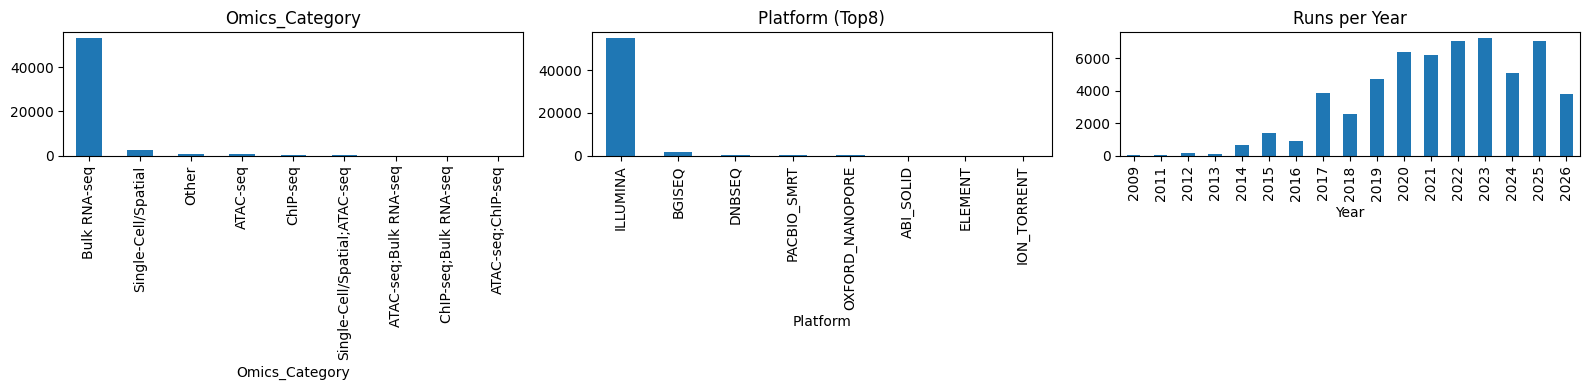

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sra['Omics_Category'].value_counts().plot(kind='bar', ax=axes[0], title='Omics_Category')
sra['Platform'].value_counts().head(8).plot(kind='bar', ax=axes[1], title='Platform (Top8)')
sra['Year'].value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Runs per Year')
plt.tight_layout()
plt.show()

## 小结

- 本数据集为玉米（含亚种）公开 RNA/表观组学测序 Run 级元数据，去重后约 5 万+ Run。
- `Omics_Category` 标签基于 Library 字段的启发式标注，建正式数据集前建议抽查。
- 过滤子集（`maize_sra_filtered.csv`）示例规则为：Zea mays + public + Bulk RNA-seq + >=1Gb。
- 下游可进一步按 `BioSample` 去重、按 `SampleName` 关键词筛组织/处理、并用 BioProject 表的 `GEO` 关联文献。